# loading

In [200]:
'''
conda deactivate
conda activate crane_test
srun --nodelist=comput76 --pty -c 4 --mem=50G jupyter lab --no-browser --port=8702 --ip=0.0.0.0
ssh 10.168.203.76 -L 8702:127.0.0.1:8702 #-R 37511:localhost:37511
'''

'\nconda deactivate\nconda activate crane_test\nsrun --nodelist=comput76 --pty -c 4 --mem=50G jupyter lab --no-browser --port=8702 --ip=0.0.0.0\nssh 10.168.203.76 -L 8702:127.0.0.1:8702 #-R 37511:localhost:37511\n'

In [201]:
'''
conda deactivate
conda activate crane_test_r
srun --nodelist=comput107 --pty -c 20 --mem=50G jupyter lab --no-browser --port=8703 --ip=0.0.0.0
ssh 10.168.203.107 -L 8703:127.0.0.1:8703 #-R 37511:localhost:37511
'''

'\nconda deactivate\nconda activate crane_test_r\nsrun --nodelist=comput107 --pty -c 20 --mem=50G jupyter lab --no-browser --port=8703 --ip=0.0.0.0\nssh 10.168.203.107 -L 8703:127.0.0.1:8703 #-R 37511:localhost:37511\n'

In [202]:
import os
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
%matplotlib inline

In [203]:
from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'  # 默认为'last'，即输出最后一个结果
InteractiveShell.ast_node_interactivity = 'all'

In [204]:
from cmapPy.pandasGEXpress.parse import parse  

In [205]:
import re

In [206]:
import pickle

In [207]:
from tqdm.auto import tqdm

# 1. genesets

## 1.1 hallmark

In [ ]:
# https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H

In [12]:
hallmark_p = '/public/home/caojun/project/crane_novel/6_benchmark/input/genesets/hs/h.all.v2024.1.Hs.symbols.gmt'
hs_gene_sets_hallmark = {}  

# 打开 .gmt 文件并逐行读取  
with open(hallmark_p, 'r') as f:  
    for line in f:  
        items = line.strip().split("\t")  # 按制表符分隔  
        gene_set_name = items[0]         # 第一列：基因集名称  
        gene_list = items[2:]            # 第三列及以后：基因列表（跳过描述列）  
        hs_gene_sets_hallmark[gene_set_name] = gene_list  


In [14]:
len(hs_gene_sets_hallmark)

50

## 1.2 3ca mps v1

In [45]:
gene_sets_mps=pd.read_csv('/public/home/caojun/project/crane_novel/6_benchmark/input/genesets/cnmf/1000mp.csv').to_dict(orient='list')  
len(gene_sets_mps)

41

In [ ]:
# GMT 文件的保存路径
mps_p = '/public/home/caojun/project/crane_novel/6_benchmark/input/genesets/cnmf/1000mp.gmt'

# 打开并写入 GMT 文件
with open(mps_p, 'w') as f:
    for gene_set_name, gene_list in gene_sets_mps.items():
        # 确保基因列表不为空
        if len(gene_list) > 0:
            # 拼接 gene_set_name 和 gene_list（基因名称用制表符分隔）
            f.write(f"{gene_set_name}\t" + "\t".join(gene_list) + "\n")

In [81]:
gene_sets_mps

{'MP1  Cell Cycle - G2/M': ['TOP2A',
  'UBE2C',
  'HMGB2',
  'NUSAP1',
  'CENPF',
  'CCNB1',
  'TPX2',
  'CKS2',
  'BIRC5',
  'PRC1',
  'PTTG1',
  'KPNA2',
  'MKI67',
  'CDC20',
  'CDK1',
  'CCNB2',
  'CDKN3',
  'SMC4',
  'NUF2',
  'ARL6IP1',
  'CKAP2',
  'ASPM',
  'PLK1',
  'CKS1B',
  'CCNA2',
  'AURKA',
  'MAD2L1',
  'GTSE1',
  'HMMR',
  'UBE2T',
  'CENPE',
  'CENPA',
  'KIF20B',
  'AURKB',
  'CDCA3',
  'CDCA8',
  'UBE2S',
  'KNSTRN',
  'KIF2C',
  'PBK',
  'TUBA1B',
  'DLGAP5',
  'TACC3',
  'STMN1',
  'DEPDC1',
  'ECT2',
  'CENPW',
  'ZWINT',
  'HIST1H4C',
  'KIF23'],
 'MP2  Cell Cycle - G1/S': ['PCNA',
  'RRM2',
  'FEN1',
  'GINS2',
  'TYMS',
  'MCM3',
  'GMNN',
  'HIST1H4C',
  'CLSPN',
  'ATAD2',
  'TK1',
  'KIAA0101',
  'DUT',
  'HELLS',
  'MCM7',
  'UBE2T',
  'MCM4',
  'CENPU',
  'DHFR',
  'ZWINT',
  'ASF1B',
  'MCM5',
  'DNAJC9',
  'RFC4',
  'HMGB2',
  'CDC6',
  'RRM1',
  'ORC6',
  'CDK1',
  'RAD51AP1',
  'RNASEH2A',
  'CHAF1A',
  'CENPK',
  'CDCA5',
  'SLBP',
  'MCM6',
  'TMEM1

## 1.3 merge

In [ ]:
# 读取一个 GMT 文件并转化为字典格式
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            # 以制表符分割每一行，第一项为基因集名称，剩余的为基因列表
            parts = line.strip().split("\t")
            gene_set_name = parts[0]
            genes = parts[1:]
            gene_sets[gene_set_name] = genes
    return gene_sets

# 读取两个 GMT 文件
hallmark_p = '/public/home/caojun/project/crane_novel/6_benchmark/input/genesets/hs/h.all.v2024.1.Hs.symbols.gmt'
mps_p = '/public/home/caojun/project/crane_novel/6_benchmark/input/genesets/cnmf/1000mp.gmt'

hallmark_gene_sets = read_gmt(hallmark_p)
mps_gene_sets = read_gmt(mps_p)

# 合并两个字典，如果有重复的基因集名称，合并基因列表
merged_gene_sets = hallmark_gene_sets.copy()

for gene_set_name, genes in mps_gene_sets.items():
    if gene_set_name in merged_gene_sets:
        # 如果基因集名重复，合并基因列表
        merged_gene_sets[gene_set_name] = list(set(merged_gene_sets[gene_set_name] + genes))
    else:
        # 如果基因集名不重复，直接添加
        merged_gene_sets[gene_set_name] = genes

# 保存合并后的数据为新的 GMT 文件
merged_gmt_p = '/public/home/caojun/project/RUSH/3_work/input/genesets/merged.gmt'
with open(merged_gmt_p, 'w') as f:
    for gene_set_name, genes in merged_gene_sets.items():
        f.write(f"{gene_set_name}\t" + "\t".join(genes) + "\n")

print(f"Combined GMT file saved to {merged_gmt_p}")


# 2. enrichment

## 2.1 test

In [15]:
import gseapy as gp

In [164]:
tt_ad = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/output/store/cp_split/cp_split_189.h5ad')

In [165]:
tt_ad.var_names = tt_ad.var['gene_symbol'].astype(str).values.copy()

In [166]:
tt_ad.var_names_make_unique()

In [167]:
tmp_p = '/public/home/caojun/project/RUSH/3_work/output/store/tmp'

In [168]:
tt_exp = pd.DataFrame(tt_ad.X,index=tt_ad.obs_names,columns=tt_ad.var_names)

In [169]:
tt_exp

,NAT2,ADA,CDH2,AKT3,MED6,NAALAD2,NAALADL1,ACOT8,ABI1,GNPDA1,...,REC8,HNRNPDL,DMTF1,PPP4R1,CDH1,SLC12A6,PTBP3,KCNE2,DGCR2,SCO2
cid,,,,,,,,,,,,,,,,,,,,,
REP.A009_JURKAT_24H:L13,-0.79070,-0.16340,-0.72370,0.22640,0.81560,-0.12240,1.25080,-0.27450,-0.32780,0.37970,...,0.68010,1.64680,0.75950,0.20490,0.05630,-0.02160,-1.51060,0.04620,-1.85450,0.39420
REP.A009_JURKAT_24H:L19,-0.47150,-2.70070,-1.18820,-2.05370,-0.56520,-1.50860,-0.52310,-0.74290,-0.28890,-0.01730,...,0.99010,1.65740,-1.51560,-0.84020,0.00220,0.23580,0.11590,1.86850,-1.56750,0.94170
REP.A009_JURKAT_24H:M01,-0.99400,0.45240,-0.86570,0.24810,-1.09290,-0.81410,-0.47960,0.92460,-2.17070,0.80330,...,2.08550,0.54280,0.16730,0.26560,-0.09590,-0.78100,-0.05790,-0.32450,-0.18990,-0.18470
REP.A009_JURKAT_24H:M07,0.10640,0.47280,-0.96780,-0.43940,-1.63790,-0.70250,0.14920,0.67740,-0.12290,-0.33920,...,0.12620,1.20760,1.83060,-1.44890,-0.76850,0.67250,0.64780,1.22750,0.16210,-0.97510
REP.A009_JURKAT_24H:M13,-1.32470,0.45220,1.26680,1.30180,-0.30610,0.52410,-0.61250,0.19730,-0.59860,-0.12350,...,0.47470,1.34230,-0.38780,-0.59000,-0.30400,-0.59870,0.69960,0.16100,-0.98890,-0.63070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REP.A011_HEK293_24H:M07,1.43395,0.91800,-0.95750,-0.55005,-0.26365,-0.09650,1.57820,0.45290,1.31970,1.27715,...,-0.46455,-0.60025,-0.16990,0.30845,0.11435,-0.67315,0.75865,0.32940,-0.25665,0.59485
REP.A011_HEK293_24H:M13,0.30920,0.43840,-0.58515,0.01975,-0.92880,-0.85925,-0.83620,-0.07660,-1.37350,0.56580,...,-0.24005,1.11725,-0.99000,-0.67140,1.66965,0.71815,-0.23305,0.78490,1.89830,-2.35270
REP.A011_HEK293_24H:M19,0.88005,0.52255,-0.11235,-0.14520,1.52650,0.73295,0.30075,-0.83190,0.46520,0.68150,...,1.97325,-0.78585,-0.86795,0.44540,1.33690,0.61920,0.74845,-0.25405,-0.72210,-0.21960


In [176]:
sub_rank = tt_exp.iloc[545,:].sort_values(ascending=False)

In [177]:
sub_rank.to_csv(f'{tmp_p}/sub_rank.rnk', sep="\t", header=None)

In [178]:
sub_rank

SCO2           0.0
NAT2           0.0
ADA            0.0
CDH2           0.0
AKT3           0.0
              ... 
GS1-600G8.3    0.0
CDH3           0.0
TANK           0.0
EGOT           0.0
ACVR2B-AS1     0.0
Name: REP.A010_JURKAT_24H:H19, Length: 12328, dtype: float32

In [179]:
sub_rank_p = '/public/home/caojun/project/RUSH/3_work/output/store/tmp/sub_rank.rnk'

In [180]:
merged_gmt_p = '/public/home/caojun/project/RUSH/3_work/input/genesets/merged.gmt'

In [182]:
try:
    gsea_results_  = gp.prerank(
        rnk=sub_rank_p,     # 使用字典格式的排序基因列表
        gene_sets=merged_gmt_p,   # 基因集的GMT文件
        outdir=None,          # 不保存文件，返回结果
        permutation_num=1000  # 默认置换次数
    )

except BaseException:
    print('aa')

2026-01-20 13:55:36,188 [WARNING] Duplicated values found in preranked stats: 99.99% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


aa


thread '<unnamed>' panicked at src/stats.rs:302:55:
called `Option::unwrap()` on a `None` value


In [181]:
 
# 运行GSEA分析
gsea_results_  = gp.prerank(
    rnk=sub_rank_p,     # 使用字典格式的排序基因列表
    gene_sets=merged_gmt_p,   # 基因集的GMT文件
    outdir=None,          # 不保存文件，返回结果
    permutation_num=1000  # 默认置换次数
)

2026-01-20 13:50:53,733 [WARNING] Duplicated values found in preranked stats: 99.99% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


thread '<unnamed>' panicked at src/stats.rs:302:55:
called `Option::unwrap()` on a `None` value
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: called `Option::unwrap()` on a `None` value

In [63]:
res_ = gsea_results_.res2d 
res_.index = res_['Term'].values.copy()

In [64]:
res_

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
MP7 Stress (in vitro),prerank,MP7 Stress (in vitro),0.591031,2.305588,0.0,0.0,0.0,16/38,14.31%,PHGDH;XBP1;SQSTM1;DDIT4;ASNS;UPP1;ATF4;PPP1R15...
MP2 Cell Cycle - G1/S,prerank,MP2 Cell Cycle - G1/S,-0.610434,-2.176167,0.0,0.0,0.0,29/43,25.76%,DNMT1;CDC6;E2F1;RRM2;CDC45;DHFR;RRM1;FEN1;MCM5...
MP21 Respiration,prerank,MP21 Respiration,-0.611729,-2.083499,0.0,0.000658,0.002,19/35,21.20%,LGALS1;NOP10;NDUFB2;UQCR10;NDUFA3;NDUFA7;COX17...
HALLMARK_APICAL_SURFACE,prerank,HALLMARK_APICAL_SURFACE,0.518219,1.931521,0.0,0.013093,0.014,11/34,10.55%,MAL;LYN;GAS1;NCOA6;IL2RG;AKAP7;DCBLD2;CX3CL1;A...
MP32 Skin-pigmentation,prerank,MP32 Skin-pigmentation,0.471158,1.840271,0.003145,0.021822,0.034,23/45,20.16%,GPR137B;PIR;WIPI1;RRAGD;BCL2A1;S100B;SH3BP5;PM...
...,...,...,...,...,...,...,...,...,...,...
MP38 Glutathione,prerank,MP38 Glutathione,0.195702,0.761026,0.876833,0.900904,1.0,15/36,29.75%,SLC22A18;CDHR5;SLC6A13;LACTB2;CFI;GSTA1;CLDN10...
HALLMARK_MYC_TARGETS_V2,prerank,HALLMARK_MYC_TARGETS_V2,-0.201078,-0.757419,0.855882,0.954417,1.0,10/56,19.36%,MRTO4;MCM5;PLK4;PRMT3;MCM4;MYC;UTP20;DDX18;AIM...
HALLMARK_TGF_BETA_SIGNALING,prerank,HALLMARK_TGF_BETA_SIGNALING,-0.194326,-0.711409,0.894661,0.979181,1.0,7/52,8.65%,MAP3K7;ID1;FURIN;SKI;XIAP;TRIM33;FNTA
MP30 PDAC-classical,prerank,MP30 PDAC-classical,-0.202718,-0.7068,0.908116,0.959534,1.0,10/38,18.84%,PLA2G10;SPINK1;ANXA10;PDE4C;AKR7A3;CES2;CTSE;L...


In [54]:
 
# 运行GSEA分析
gsea_results_  = gp.prerank(
    rnk=sub_rank_p,     # 使用字典格式的排序基因列表
    gene_sets=hallmark_p,   # 基因集的GMT文件
    outdir=None,          # 不保存文件，返回结果
    permutation_num=1000  # 默认置换次数
)

2026-01-17 20:01:35,527 [WARNING] Duplicated values found in preranked stats: 0.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [55]:
gsea_results_.res2d

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_APICAL_SURFACE,0.518219,1.931521,0.0,0.006946,0.003,11/34,10.55%,MAL;LYN;GAS1;NCOA6;IL2RG;AKAP7;DCBLD2;CX3CL1;A...
1,prerank,HALLMARK_E2F_TARGETS,-0.395518,-1.804451,0.0,0.008706,0.015,81/186,30.53%,RAD51C;DNMT1;CDKN2A;RPA3;EZH2;EXOSC8;MLH1;PPM1...
2,prerank,HALLMARK_NOTCH_SIGNALING,0.498973,1.765543,0.002994,0.011576,0.01,10/28,10.92%,FZD1;ST3GAL6;FZD7;NOTCH3;PSEN2;TCF7L2;NOTCH2;F...
3,prerank,HALLMARK_ESTROGEN_RESPONSE_EARLY,0.311202,1.64295,0.0,0.036271,0.046,44/198,13.15%,TSKU;SLC1A4;WFS1;XBP1;RAB31;TIPARP;MINDY1;EGR3...
4,prerank,HALLMARK_TNFA_SIGNALING_VIA_NFKB,0.301839,1.582371,0.0,0.035886,0.06,58/198,20.64%,EGR1;BIRC2;TIPARP;SQSTM1;EGR3;ICAM1;TRIP10;FOS...
5,prerank,HALLMARK_COAGULATION,-0.363454,-1.567085,0.001316,0.052815,0.17,46/134,24.15%,CSRP1;RABIF;ADAM9;C8B;C3;CTSH;C2;C1S;CPB2;FURI...
6,prerank,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,0.320756,1.542861,0.003831,0.043063,0.09,25/109,11.96%,SLC1A4;WFS1;XBP1;TSPYL2;DDIT4;ASNS;PAIP1;SRPRB...
7,prerank,HALLMARK_UV_RESPONSE_UP,0.288736,1.468692,0.0,0.06251,0.148,36/156,15.54%,LYN;SQSTM1;SIGMAR1;HNRNPU;ICAM1;EPHX1;HMOX1;PR...
8,prerank,HALLMARK_MYOGENESIS,-0.318743,-1.447921,0.002433,0.127104,0.475,71/193,26.90%,TAGLN;AKT2;FDPS;MYH4;ACTC1;MYH11;MYH8;REEP1;AP...
9,prerank,HALLMARK_G2M_CHECKPOINT,-0.303642,-1.394607,0.011568,0.164248,0.683,75/194,30.23%,NUSAP1;EZH2;HSPA8;TOP1;CDC6;E2F1;MNAT1;CDC45;M...


## 2.2 large

In [ ]:
#sbatch /public/home/caojun/project/RUSH/3_work/script/cp_gsea_eval.sh 189

In [66]:
%%bash 
#!/bin/bash  
script_path="/public/home/caojun/project/RUSH/3_work/script/cp_gsea_eval.sh"


# 遍历 0 到 201
for dataid in {0..201}
do
  # 提交 sbatch 作业，传递 dataid
  sbatch $script_path $dataid
done

Submitted batch job 1033124


Submitted batch job 1033125
Submitted batch job 1033126
Submitted batch job 1033127
Submitted batch job 1033128
Submitted batch job 1033129
Submitted batch job 1033130
Submitted batch job 1033131
Submitted batch job 1033132
Submitted batch job 1033133
Submitted batch job 1033134
Submitted batch job 1033135
Submitted batch job 1033136
Submitted batch job 1033137
Submitted batch job 1033138
Submitted batch job 1033139
Submitted batch job 1033140
Submitted batch job 1033141
Submitted batch job 1033142
Submitted batch job 1033143
Submitted batch job 1033144
Submitted batch job 1033145
Submitted batch job 1033146
Submitted batch job 1033147
Submitted batch job 1033148
Submitted batch job 1033149
Submitted batch job 1033150
Submitted batch job 1033151
Submitted batch job 1033152
Submitted batch job 1033153
Submitted batch job 1033154
Submitted batch job 1033155
Submitted batch job 1033156
Submitted batch job 1033157
Submitted batch job 1033158
Submitted batch job 1033159
Submitted batch job 

In [67]:
%%bash 
#!/bin/bash  
script_path="/public/home/caojun/project/RUSH/3_work/script/sh_gsea_eval.sh"


# 遍历 0 到 189
for dataid in {0..189}
do
  # 提交 sbatch 作业，传递 dataid
  sbatch $script_path $dataid
done

Submitted batch job 1033331
Submitted batch job 1033332
Submitted batch job 1033333
Submitted batch job 1033334
Submitted batch job 1033335
Submitted batch job 1033336
Submitted batch job 1033337
Submitted batch job 1033338
Submitted batch job 1033339
Submitted batch job 1033340
Submitted batch job 1033341
Submitted batch job 1033342
Submitted batch job 1033343
Submitted batch job 1033344
Submitted batch job 1033345
Submitted batch job 1033346
Submitted batch job 1033347
Submitted batch job 1033348
Submitted batch job 1033349
Submitted batch job 1033350
Submitted batch job 1033351
Submitted batch job 1033352
Submitted batch job 1033353
Submitted batch job 1033354
Submitted batch job 1033355
Submitted batch job 1033356
Submitted batch job 1033357
Submitted batch job 1033358
Submitted batch job 1033359
Submitted batch job 1033360
Submitted batch job 1033361
Submitted batch job 1033362
Submitted batch job 1033363
Submitted batch job 1033364
Submitted batch job 1033365
Submitted batch job 

In [69]:
%%bash 
#!/bin/bash  
script_path="/public/home/caojun/project/RUSH/3_work/script/xpr_gsea_eval.sh"


# 遍历 0 到 132
for dataid in {0..132}
do
  # 提交 sbatch 作业，传递 dataid
  sbatch $script_path $dataid
done

Submitted batch job 1033722
Submitted batch job 1033723
Submitted batch job 1033724
Submitted batch job 1033725
Submitted batch job 1033726
Submitted batch job 1033727
Submitted batch job 1033728
Submitted batch job 1033729
Submitted batch job 1033730
Submitted batch job 1033731
Submitted batch job 1033732
Submitted batch job 1033733
Submitted batch job 1033734
Submitted batch job 1033735
Submitted batch job 1033736
Submitted batch job 1033737
Submitted batch job 1033738
Submitted batch job 1033739
Submitted batch job 1033740
Submitted batch job 1033741
Submitted batch job 1033742
Submitted batch job 1033743
Submitted batch job 1033744
Submitted batch job 1033745
Submitted batch job 1033746
Submitted batch job 1033747
Submitted batch job 1033748
Submitted batch job 1033749
Submitted batch job 1033750
Submitted batch job 1033751
Submitted batch job 1033752
Submitted batch job 1033753
Submitted batch job 1033754
Submitted batch job 1033755
Submitted batch job 1033756
Submitted batch job 

# 3. curating

## 3.1 cp

In [183]:
gsea_p = '/public/home/caojun/project/RUSH/3_work/output/store/gsea_res'

In [184]:
hallmark_terms = list(hs_gene_sets_hallmark.keys())
mps_terms = list(gene_sets_mps.keys())
func_terms = hallmark_terms + mps_terms

In [185]:
cols = []  # 存每个样本的一列（Series）

for i in tqdm(range(202), desc="Loading pkl"):
    with open(f'{gsea_p}/cp_gsea_res_{i}.pkl','rb') as f:
        gse_res = pickle.load(f)

    for j, df in gse_res.items():
        dfj = df.loc[func_terms, ['NES', 'FDR q-val']]
        score = dfj['NES'].astype(float) * -np.log10(dfj['FDR q-val'].astype(float) + 1e-10)
        score.name = j
        cols.append(score)

func_df = pd.concat(cols, axis=1)

Loading pkl:   0%|          | 0/202 [00:00<?, ?it/s]

In [186]:
func_df.to_csv('/public/home/caojun/project/RUSH/3_work/output/table/gsea_res/cp_gsea_100terms.csv')

In [191]:
cp_adata = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/input/cmap_cp_ad.h5ad',backed='r')

In [188]:
np.max(func_df)

62.98036081587327

In [189]:
np.min(func_df)

-66.77802366674993

In [192]:
cp_func_ad = ad.AnnData(func_df.T)
cp_func_ad.obs = cp_adata.obs.loc[cp_func_ad.obs_names,['sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time']].copy()
cp_func_ad.write('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/cp_func_ad.h5ad')

In [193]:
cp_func_ad

AnnData object with n_obs × n_vars = 201014 × 91
    obs: 'sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time'

## 3.2 sh

In [133]:
gsea_p = '/public/home/caojun/project/RUSH/3_work/output/store/gsea_res'

In [134]:
hallmark_terms = list(hs_gene_sets_hallmark.keys())
mps_terms = list(gene_sets_mps.keys())
func_terms = hallmark_terms + mps_terms

In [135]:
cols = []  # 存每个样本的一列（Series）

for i in tqdm(range(190), desc="Loading pkl"):
    with open(f'{gsea_p}/sh_gsea_res_{i}.pkl','rb') as f:
        gse_res = pickle.load(f)

    for j, df in gse_res.items():
        dfj = df.loc[func_terms, ['NES', 'FDR q-val']]
        score = dfj['NES'].astype(float) * -np.log10(dfj['FDR q-val'].astype(float) + 1e-10)
        score.name = j
        cols.append(score)

func_df = pd.concat(cols, axis=1)

Loading pkl:   0%|          | 0/190 [00:00<?, ?it/s]

In [139]:
func_df.to_csv('/public/home/caojun/project/RUSH/3_work/output/table/gsea_res/sh_gsea_100terms.csv')

In [140]:
sh_adata = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/input/cmap_sh_ad_unique.h5ad',backed='r')

,sig_id,project_code,cell_iname,pert_id,cmap_name,pert_dose,pert_time
cid,,,,,,,
CGS001_A375_96H:A2M:1,CGS001_A375_96H:A2M:1,CGS,A375,CGS001-2,A2M,1.0,96.0
CGS001_A375_96H:AARS:1,CGS001_A375_96H:AARS:1,CGS,A375,CGS001-16,AARS,1.0,96.0
CGS001_A375_96H:AATF:1,CGS001_A375_96H:AATF:1,CGS,A375,CGS001-26574,AATF,1.0,96.0
CGS001_A375_96H:ABAT:1,CGS001_A375_96H:ABAT:1,CGS,A375,CGS001-18,ABAT,1.0,96.0
CGS001_A375_96H:ABCA1:1,CGS001_A375_96H:ABCA1:1,CGS,A375,CGS001-19,ABCA1,1.0,96.0
...,...,...,...,...,...,...,...
TAK004_U2OS_96H:TRCN0000370007:1,TAK004_U2OS_96H:TRCN0000370007:1,TAK,U2OS,TRCN0000370007,WWTR1,1.0,96.0
TAK004_U2OS_96H:TRCN0000370678:1,TAK004_U2OS_96H:TRCN0000370678:1,TAK,U2OS,TRCN0000370678,GRB10,1.0,96.0
TAK004_U2OS_96H:TRCN0000370697:1,TAK004_U2OS_96H:TRCN0000370697:1,TAK,U2OS,TRCN0000370697,GRB10,1.0,96.0


In [137]:
np.max(func_df)

66.03531385645942

In [138]:
np.min(func_df)

-65.54070081006537

In [147]:
sh_func_ad = ad.AnnData(func_df.T)
sh_func_ad.obs = sh_adata.obs[['sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time']].copy()
sh_func_ad.write('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/sh_func_ad.h5ad')

In [148]:
sh_func_ad

AnnData object with n_obs × n_vars = 189365 × 91
    obs: 'sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time'

## 3.3 xpr

In [149]:
gsea_p = '/public/home/caojun/project/RUSH/3_work/output/store/gsea_res'

In [150]:
hallmark_terms = list(hs_gene_sets_hallmark.keys())
mps_terms = list(gene_sets_mps.keys())
func_terms = hallmark_terms + mps_terms

In [152]:
cols = []  # 存每个样本的一列（Series）

for i in tqdm(range(133), desc="Loading pkl"):
    with open(f'{gsea_p}/xpr_gsea_res_{i}.pkl','rb') as f:
        gse_res = pickle.load(f)

    for j, df in gse_res.items():
        dfj = df.loc[func_terms, ['NES', 'FDR q-val']]
        score = dfj['NES'].astype(float) * -np.log10(dfj['FDR q-val'].astype(float) + 1e-10)
        score.name = j
        cols.append(score)

func_df = pd.concat(cols, axis=1)

Loading pkl:   0%|          | 0/133 [00:00<?, ?it/s]

In [153]:
func_df.to_csv('/public/home/caojun/project/RUSH/3_work/output/table/gsea_res/xpr_gsea_100terms.csv')

In [154]:
xpr_adata = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/input/cmap_xpr_ad_unique.h5ad',backed='r')

,sig_id,project_code,cell_iname,pert_id,cmap_name,pert_dose,pert_time
cid,,,,,,,
CGS001_A375_96H:A2M:1,CGS001_A375_96H:A2M:1,CGS,A375,CGS001-2,A2M,1.0,96.0
CGS001_A375_96H:AARS:1,CGS001_A375_96H:AARS:1,CGS,A375,CGS001-16,AARS,1.0,96.0
CGS001_A375_96H:AATF:1,CGS001_A375_96H:AATF:1,CGS,A375,CGS001-26574,AATF,1.0,96.0
CGS001_A375_96H:ABAT:1,CGS001_A375_96H:ABAT:1,CGS,A375,CGS001-18,ABAT,1.0,96.0
CGS001_A375_96H:ABCA1:1,CGS001_A375_96H:ABCA1:1,CGS,A375,CGS001-19,ABCA1,1.0,96.0
...,...,...,...,...,...,...,...
TAK004_U2OS_96H:TRCN0000370007:1,TAK004_U2OS_96H:TRCN0000370007:1,TAK,U2OS,TRCN0000370007,WWTR1,1.0,96.0
TAK004_U2OS_96H:TRCN0000370678:1,TAK004_U2OS_96H:TRCN0000370678:1,TAK,U2OS,TRCN0000370678,GRB10,1.0,96.0
TAK004_U2OS_96H:TRCN0000370697:1,TAK004_U2OS_96H:TRCN0000370697:1,TAK,U2OS,TRCN0000370697,GRB10,1.0,96.0


In [155]:
np.max(func_df)

50.697070649047276

In [156]:
np.min(func_df)

-61.18713765018213

In [157]:
xpr_func_ad = ad.AnnData(func_df.T)
xpr_func_ad.obs = xpr_adata.obs[['sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time']].copy()
xpr_func_ad.write('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/xpr_func_ad.h5ad')

In [158]:
xpr_func_ad

AnnData object with n_obs × n_vars = 132464 × 91
    obs: 'sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time'

# 4. visulation

In [219]:
cp_func_ad = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/cp_func_ad.h5ad')

In [220]:
cp_func_ad

AnnData object with n_obs × n_vars = 201014 × 91
    obs: 'sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'score', 'score_clip'
    obsp: 'connectivities', 'distances'

In [223]:
len(cp_func_ad.obs['cell_iname'].unique())
len(cp_func_ad.obs['pert_id'].unique())
len(cp_func_ad.obs['cmap_name'].unique())

229

34413

33605

In [213]:
#cp_func_ad.layers['score'] = cp_func_ad.X.copy() 
#cp_func_ad.layers['score_clip'] = np.clip(cp_func_ad.layers['score'],10,-10)
#cp_func_ad.X = cp_func_ad.layers['score_clip'].copy()

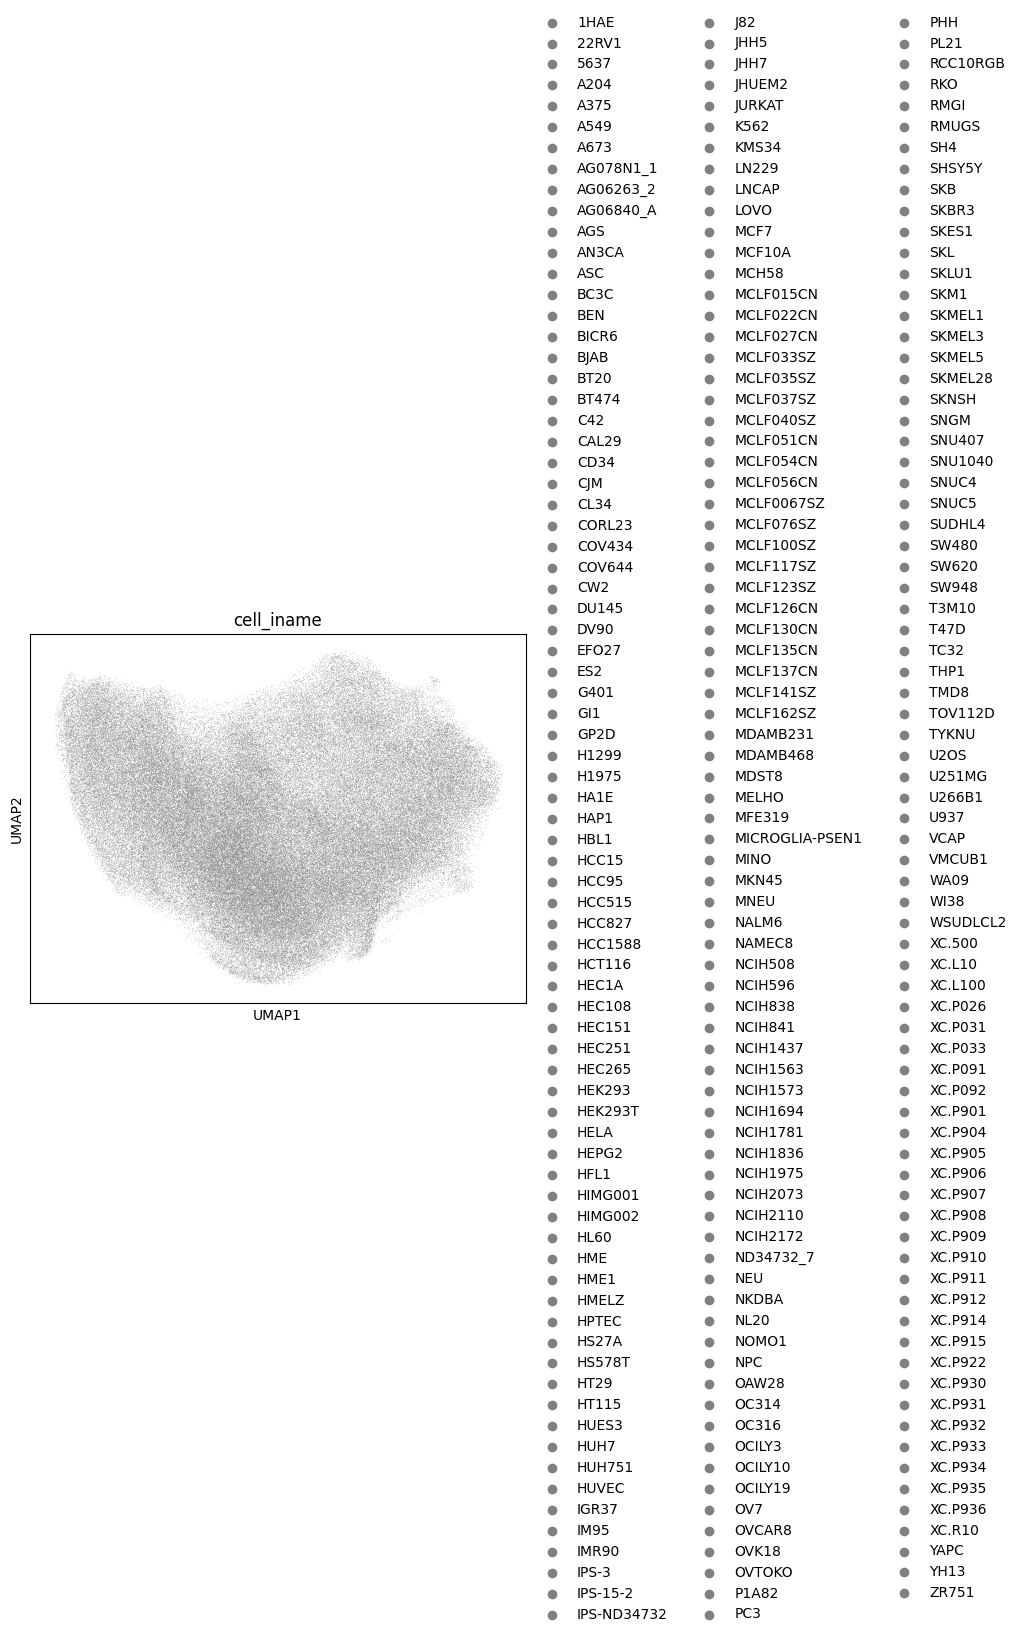

In [229]:
sc.pl.umap(cp_func_ad,
           color=['cell_iname',],# 'pert_id', 'cmap_name'],
           color_map='inferno',
           #save="_umap_4genes_test_counts.pdf",
           #layer='counts'
           )

In [208]:
cp_func_ad

AnnData object with n_obs × n_vars = 201014 × 91
    obs: 'sig_id', 'project_code', 'cell_iname', 'pert_id', 'cmap_name', 'pert_dose', 'pert_time'

In [224]:
sh_func_ad = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/sh_func_ad.h5ad')

In [225]:
len(sh_func_ad.obs['cell_iname'].unique())
len(sh_func_ad.obs['pert_id'].unique())
len(sh_func_ad.obs['cmap_name'].unique())

22

27920

8767

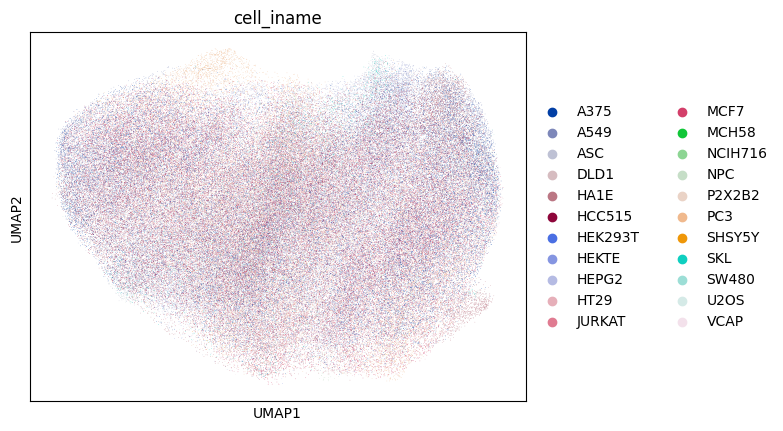

In [228]:
sc.pl.umap(sh_func_ad,
           color=['cell_iname',],# 'pert_id', 'cmap_name'],
           color_map='inferno',
           #save="_umap_4genes_test_counts.pdf",
           #layer='counts'
           )

In [230]:
xpr_func_ad = sc.read_h5ad('/public/home/caojun/project/RUSH/3_work/output/store/gsea_anndata/xpr_func_ad.h5ad')

In [232]:
xpr_func_ad.obs

,sig_id,project_code,cell_iname,pert_id,cmap_name,pert_dose,pert_time
cid,,,,,,,
XPR025_BICR6.311_96H:E13,XPR025_BICR6.311_96H:E13,XPR,BICR6,BRDN0001584713,STAC,0.0,96.0
XPR022_ES2.311_96H:N08,XPR022_ES2.311_96H:N08,XPR,ES2,BRDN0001494955,RELL1,0.0,96.0
XPR028_PC3.311B_96H:J15,XPR028_PC3.311B_96H:J15,XPR,PC3,BRDN0001486333,SLC19A3,0.0,96.0
XPR015_A375.311_96H:E11,XPR015_A375.311_96H:E11,XPR,A375,BRDN0001500062,CPVL,0.0,96.0
XPR013_ES2.311_96H:J04,XPR013_ES2.311_96H:J04,XPR,ES2,BRDN0001584259,CD300LB,0.0,96.0
...,...,...,...,...,...,...,...
XPR039_DANG.311_96H:K14,XPR039_DANG.311_96H:K14,XPR,DANG,BRDN0001480723,CYTH2,0.0,96.0
XPR034_YAPC.311_96H:A06,XPR034_YAPC.311_96H:A06,XPR,YAPC,BRDN0001149166,IP6K1,0.0,96.0
XPR031_YAPC.311_96H:N09,XPR031_YAPC.311_96H:N09,XPR,YAPC,BRDN0001586291,PIK3AP1,0.0,96.0


In [226]:
len(xpr_func_ad.obs['cell_iname'].unique())
len(xpr_func_ad.obs['pert_id'].unique())
len(xpr_func_ad.obs['cmap_name'].unique())

26

13466

5155

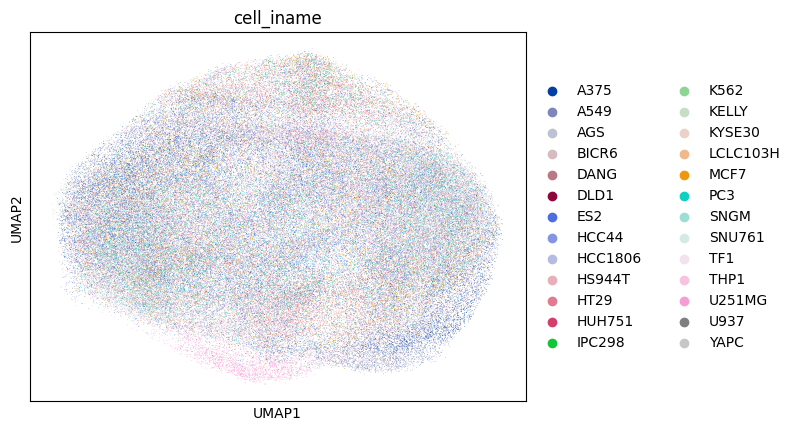

In [231]:
sc.pl.umap(xpr_func_ad,
           color=['cell_iname',],# 'pert_id', 'cmap_name'],
           color_map='inferno',
           #save="_umap_4genes_test_counts.pdf",
           #layer='counts'
           )